# Spin–spin correlations with MPS-CPMC: half-filled 4×4 Hubbard

`observable_names=("szsz",)` makes every block also measure the **mixed estimator**
⟨T|S^z_i S^z_j|φ⟩ / ⟨T|φ⟩, weighted over the walkers like the energy. The result is an (L, L) matrix per block.
It works for a trial with (N_up, N_dn) bond labels (here) and for a spin-rotated trial used as it is.
Open 4×4, 8↑ + 8↓, U = 4, t = 1. The settings below are a quick look (walker χ = 16); raise `walker_channel_chi`
and `n_walkers` for production numbers.

In [ ]:
from trot import config

config.configure_once()  # precision; before importing jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from trot.core.system import System
from trot.gmps.dmrg import make_dmrg_trial
from trot.gmps.driver import run_qmc_mps
from trot.gmps.engine import szsz_dense
from trot.ham.hubbard import HamHubbard, square_hopping_matrix
from trot.prop.types import QmcParamsMps

Lx = Ly = 4
U = 4.0
N = Lx * Ly
h1 = square_hopping_matrix(Lx, Ly, 1.0)  # open boundaries, site = x * Ly + y
sys = System(N, (N // 2, N // 2), "unrestricted")  # half filling
ham = HamHubbard(jnp.asarray(h1), U)
params = QmcParamsMps(
    n_walkers=32,
    n_eql_blocks=10,
    n_blocks=30,
    dt=0.01,
    n_prop_steps=20,  # a block is 0.2 tau
    weight_floor=1e-8,
    seed=3,
    trial_chi=128,
    walker_channel_chi=16,
)
REF_CHI = 1024  # DMRG reference for the plots

In [ ]:
trial = make_dmrg_trial(ham, sys, chi=params.trial_chi, n_sweeps=params.dmrg_sweeps).trial
result = run_qmc_mps(sys=sys, params=params, ham_data=ham, trial_data=trial, observable_names=("szsz",))
print(f"E = {float(result.mean_energy):.4f} +/- {float(result.stderr_energy):.4f}")

MPO site   0 / 16 .. D = 6
MPO site   1 / 16 .. D = 10
MPO site   2 / 16 .. D = 14
MPO site   3 / 16 .. D = 18
MPO site   4 / 16 .. D = 18
MPO site   5 / 16 .. D = 18
MPO site   6 / 16 .. D = 18
MPO site   7 / 16 .. D = 18
MPO site   8 / 16 .. D = 18
MPO site   9 / 16 .. D = 18
MPO site  10 / 16 .. D = 18
MPO site  11 / 16 .. D = 18
MPO site  12 / 16 .. D = 14
MPO site  13 / 16 .. D = 10
MPO site  14 / 16 .. D = 6
MPO site  15 / 16 .. D = 1
MPS trial: bonds [1, 4, 16, 64, 256, 256, 256, 256, 256, 256, 256, 256, 256, 64, 16, 4, 1]
  <T|H|T>/<T|T> = -11.130862140378 (blocked kernel, H|T> bonds max 4092)
  setup: walker_plan 0.1 s, meas_ctx 22.8 s, walker_start 3.2 s
walker plan: adaptive gates 64, 64; reference natural; walker bonds max 256
  channel a: reference discarded weight 1.276e-02
  channel b: reference discarded weight 1.164e-02
  walkers start from the natural determinant; orbital-plan infidelity 1.1e-15, -4.9e-15
  start: overlap 4.423047e-01, local energy -11.1837039048
  en

The trial's own ⟨S^z_i S^z_j⟩ (an MPS expectation) gives the extrapolated estimator 2·mixed − trial, and a larger DMRG
(χ = 512) gives the reference.

In [ ]:
ref = make_dmrg_trial(ham, sys, chi=REF_CHI, n_sweeps=params.dmrg_sweeps)
print(f"E_DMRG(chi={REF_CHI}) = {ref.variational_energy:.4f}")
C_trial = np.asarray(szsz_dense(trial.tensors, trial.tensors))
C_ref = np.asarray(szsz_dense(ref.trial.tensors, ref.trial.tensors))
C_mix = np.asarray(result.observable_means["szsz"])
C_err = np.asarray(result.observable_stderrs["szsz"])
C_ext = 2 * C_mix - C_trial

r0 = 1 * Ly + 1  # reference site (x, y) = (1, 1)
xy = np.array([(s // Ly, s % Ly) for s in range(N)])
dist = np.linalg.norm(xy - xy[r0], axis=1)
print(f"sum rule  sum_j <S0 Sj> = {C_mix[r0].sum():.2e} (0 for S_z = 0);  <S0 S0> = {C_mix[r0, r0]:.4f}")

MPO site   0 / 16 .. D = 6
MPO site   1 / 16 .. D = 10
MPO site   2 / 16 .. D = 14
MPO site   3 / 16 .. D = 18
MPO site   4 / 16 .. D = 18
MPO site   5 / 16 .. D = 18
MPO site   6 / 16 .. D = 18
MPO site   7 / 16 .. D = 18
MPO site   8 / 16 .. D = 18
MPO site   9 / 16 .. D = 18
MPO site  10 / 16 .. D = 18
MPO site  11 / 16 .. D = 18
MPO site  12 / 16 .. D = 14
MPO site  13 / 16 .. D = 10
MPO site  14 / 16 .. D = 6
MPO site  15 / 16 .. D = 1
E_DMRG(chi=512) = -11.2208
sum rule  sum_j <S0 Sj> = -5.55e-17 (0 for S_z = 0);  <S0 S0> = 0.1941


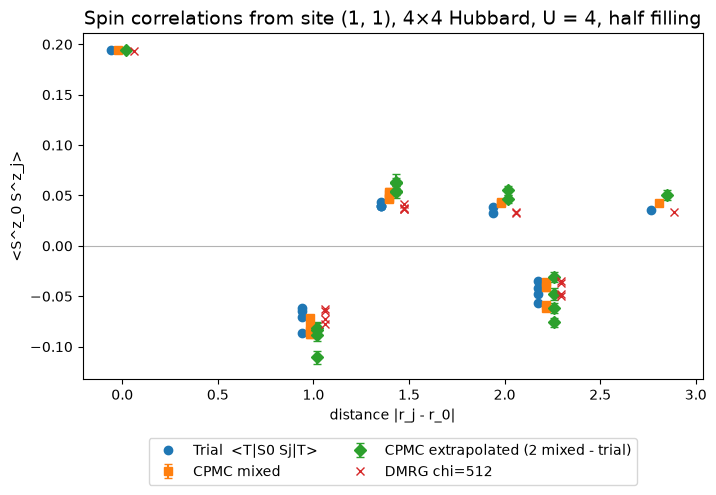

In [ ]:
order = np.argsort(dist, kind="stable")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="0.7", lw=0.8)
series = [
    (C_trial[r0], None, "o", "Trial  <T|S0 Sj|T>"),
    (C_mix[r0], C_err[r0], "s", "CPMC mixed"),
    (C_ext[r0], 2 * C_err[r0], "D", "CPMC extrapolated (2 mixed - trial)"),
    (C_ref[r0], None, "x", f"DMRG chi={REF_CHI}"),
]
for k, (values, err, marker, label) in enumerate(series):
    shift = 0.04 * (k - 1.5)
    ax.errorbar(dist[order] + shift, values[order], yerr=None if err is None else err[order], fmt=marker, capsize=3,
                label=label)
ax.set_xlabel("distance |r_j - r_0|")
ax.set_ylabel("<S^z_0 S^z_j>")
ax.set_title("Spin correlations from site (1, 1), 4×4 Hubbard, U = 4, half filling", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

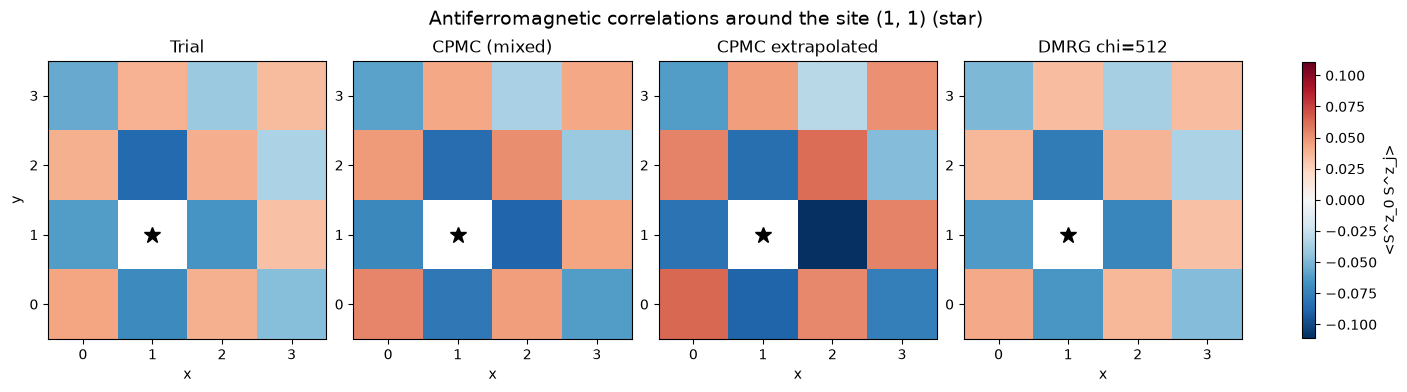

In [ ]:
maps = [("Trial", C_trial), ("CPMC (mixed)", C_mix), ("CPMC extrapolated", C_ext), (f"DMRG chi={REF_CHI}", C_ref)]
off = np.arange(N) != r0  # the on-site value <Sz^2> would set the colour scale
vmax = max(np.abs(m[r0, off]).max() for _, m in maps)
fig, axes = plt.subplots(1, len(maps), figsize=(14, 3.8), constrained_layout=True)
for ax, (name, m) in zip(axes, maps):
    row = m[r0].reshape(Lx, Ly).copy()
    row[r0 // Ly, r0 % Ly] = np.nan  # the on-site value dominates the scale
    im = ax.imshow(row.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.plot(r0 // Ly, r0 % Ly, "k*", ms=12)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("x")
    ax.set_xticks(range(Lx)), ax.set_yticks(range(Ly))
axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes, shrink=0.85, label="<S^z_0 S^z_j>")
fig.suptitle("Antiferromagnetic correlations around the site (1, 1) (star)", fontsize=14)
plt.show()

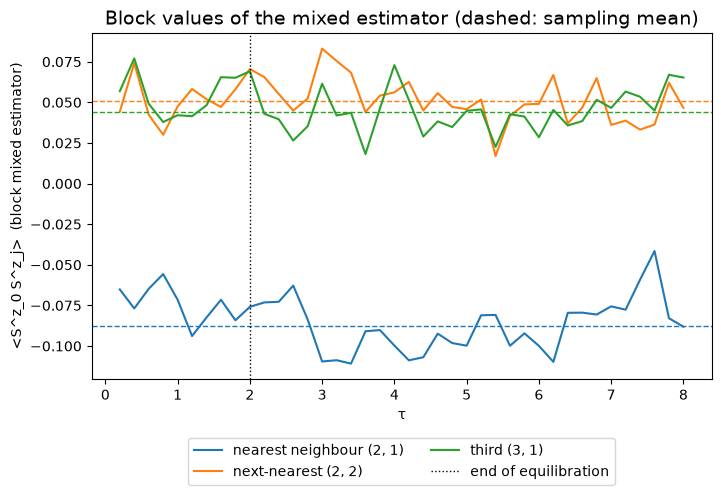

In [ ]:
tau = (np.arange(len(result.block_observables["szsz"])) + 1) * params.n_prop_steps * params.dt
blocks = np.asarray(result.block_observables["szsz"])  # (blocks, L, L)
partners = {"nearest neighbour (2, 1)": 2 * Ly + 1, "next-nearest (2, 2)": 2 * Ly + 2, "third (3, 1)": 3 * Ly + 1}
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, j in partners.items():
    line, = ax.plot(tau, blocks[:, r0, j], label=label)
    ax.axhline(C_mix[r0, j], color=line.get_color(), ls="--", lw=1)
ax.axvline(params.n_eql_blocks * params.n_prop_steps * params.dt, color="k", ls=":", lw=1, label="end of equilibration")
ax.set_xlabel("τ")
ax.set_ylabel("<S^z_0 S^z_j>  (block mixed estimator)")
ax.set_title("Block values of the mixed estimator (dashed: sampling mean)", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()